In [1]:
from shock_response.srs import CudaSRS, TorchSRS
import torch

torch.set_printoptions(precision=6, sci_mode=False)

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float64

print("device:", device)
if device == "cuda":
    print("gpu:", torch.cuda.get_device_name(0))


device: cuda
gpu: Quadro T1000 with Max-Q Design


In [3]:
fs = 32768
damping = 0.03
freqs = torch.tensor([50.0, 100.0, 200.0, 500.0, 1000.0, 2000.0], device=device, dtype=dtype)

B = 3
T = 1024
F = freqs.size(-1)

torch.manual_seed(0)
x = torch.randn(B, 1, T, device=device, dtype=dtype)

cuda_model = CudaSRS(freqs, damping=damping, fs=fs).to(device)
torch_model = TorchSRS(freqs, damping=damping, fs=fs).to(device)

print("x shape:", tuple(x.shape))
print("num filters:", freqs.numel())
print("cuda As shape:", tuple(cuda_model.As.shape))
print("torch As shape:", tuple(torch_model.As.shape))


x shape: (3, 1, 1024)
num filters: 6
cuda As shape: (6, 2)
torch As shape: (6, 3)


### Forward test


In [4]:
with torch.no_grad():
    srs_cuda_out = cuda_model(x)
    srs_torch_out = torch_model(x)

forward_max_abs_diff = (srs_cuda_out - srs_torch_out).abs().max().item()
forward_rel_diff = ((srs_cuda_out - srs_torch_out).abs() / srs_torch_out.abs().clamp_min(1e-12)).max().item()

print("max absolute forward diff:", forward_max_abs_diff)
print("max relative forward diff:", forward_rel_diff)

max absolute forward diff: 6.239133654162288e-10
max relative forward diff: 8.950479290260996e-14


In [5]:
print("CUDA forward sample:")
print(srs_cuda_out[:2, :4])

print("\nTorch forward sample:")
print(srs_torch_out[:2, :4])

CUDA forward sample:
tensor([[12417.008191,  3490.471139,  1433.470892,   484.222471],
        [11230.626065,  4469.158786,  1936.770286,   806.204954]],
       device='cuda:0', dtype=torch.float64)

Torch forward sample:
tensor([[12417.008191,  3490.471139,  1433.470892,   484.222471],
        [11230.626065,  4469.158786,  1936.770286,   806.204954]],
       device='cuda:0', dtype=torch.float64)


### Backward test


In [6]:
torch.manual_seed(1)
x_cuda = torch.randn(B, T, device=device, dtype=dtype, requires_grad=True)
x_chunk = x_cuda.detach().clone().requires_grad_(True)
x_torch = x_cuda.detach().clone().requires_grad_(True)

weights = torch.randn(B, freqs.numel(), device=device, dtype=dtype)

loss_cuda = (cuda_model(x_cuda) * weights).sum() # ChatGPT did this as a way to just get to a scalar
loss_torch = (torch_model(x_torch) * weights).sum()

loss_cuda.backward()
loss_torch.backward()

grad_cuda = x_cuda.grad
grad_torch = x_torch.grad

grad_max_abs_diff = (grad_cuda - grad_torch).abs().max().item()
grad_rel_diff = ((grad_cuda - grad_torch).abs() / grad_torch.abs().clamp_min(1e-12)).max().item()
grad_l2 = torch.norm(grad_cuda - grad_torch).item()

print("loss_cuda :", loss_cuda.item())
print("loss_torch:", loss_torch.item())
print("max absolute grad diff:", grad_max_abs_diff)
print("max relative grad diff:", grad_rel_diff)
print("L2 grad diff:", grad_l2)


loss_cuda : -5423.483077543695
loss_torch: -5423.483077542378
max absolute grad diff: 1.1368683772161603e-13
max relative grad diff: 1.3060790284596075e-13
L2 grad diff: 1.364652785170982e-12


In [7]:
print("CUDA grad sample:")
print(grad_cuda[:2, :8])

print("\nTorch grad sample:")
print(grad_torch[:2, :8])

print("\nGrad diff sample:")
print((grad_cuda - grad_torch)[:2, :8])

CUDA grad sample:
tensor([[-96.896355, -96.395352, -95.889772, -95.379153, -94.863041, -94.341003,
         -93.812624, -93.277512],
        [ 23.765679,  25.175144,  26.615599,  28.086300,  29.586158,  31.113746,
          32.667309,  34.244779]], device='cuda:0', dtype=torch.float64)

Torch grad sample:
tensor([[-96.896355, -96.395352, -95.889772, -95.379153, -94.863041, -94.341003,
         -93.812624, -93.277512],
        [ 23.765679,  25.175144,  26.615599,  28.086300,  29.586158,  31.113746,
          32.667309,  34.244779]], device='cuda:0', dtype=torch.float64)

Grad diff sample:
tensor([[ 0.000000,  0.000000, -0.000000,  0.000000,  0.000000, -0.000000,
         -0.000000,  0.000000],
        [ 0.000000,  0.000000,  0.000000,  0.000000, -0.000000,  0.000000,
          0.000000, -0.000000]], device='cuda:0', dtype=torch.float64)


### Forward time comparison

In [8]:
import math

fs = 32768
damping = 0.03

B = 8
T = 8192
F = 64
freqs = torch.logspace(1, math.log10(4000), F, device=device, dtype=dtype)


torch.manual_seed(0)
x = torch.randn(B, T, device=device, dtype=dtype)

cuda_model = CudaSRS(freqs, damping=damping, fs=fs).to(device)
torch_model = TorchSRS(freqs, damping=damping, fs=fs).to(device)

print("x shape:", tuple(x.shape))
print("num filters:", freqs.numel())
print("cuda As shape:", tuple(cuda_model.As.shape))
print("torch As shape:", tuple(torch_model.As.shape))

x shape: (8, 8192)
num filters: 64
cuda As shape: (64, 2)
torch As shape: (64, 3)


In [9]:
def benchmark_forward(model, x, iters=100, warmup=10):
    for _ in range(warmup):
        model(x)
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(iters):
        model(x)
    end.record()

    torch.cuda.synchronize()
    return start.elapsed_time(end) / iters  # ms


t_cuda = benchmark_forward(cuda_model, x)
t_torch = benchmark_forward(torch_model, x)

print(f"CUDA forward:    {t_cuda:.3f} ms")
print(f"lfilter forward: {t_torch:.3f} ms")

CUDA forward:    6.241 ms
lfilter forward: 11.755 ms


In [10]:
def benchmark_backward(model, x, grad_out, iters=100, warmup=10):
    x = x.detach().clone().requires_grad_(True)

    for _ in range(warmup):
        y = model(x)
        if x.grad is not None:
            x.grad.zero_()
        y.backward(grad_out, retain_graph=False)
    torch.cuda.synchronize()

    times = []
    for _ in range(iters):
        y = model(x)
        if x.grad is not None:
            x.grad.zero_()

        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)

        start.record()
        y.backward(grad_out, retain_graph=False)
        end.record()

        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))

    return sum(times) / len(times)

with torch.no_grad():
    grad_out = torch.randn_like(cuda_model(x))

t_cuda_bwd = benchmark_backward(cuda_model, x, grad_out)
t_torch_bwd = benchmark_backward(torch_model, x, grad_out)

print(f"CUDA backward:    {t_cuda_bwd:.3f} ms")
print(f"lfilter backward: {t_torch_bwd:.3f} ms")

CUDA backward:    5.027 ms
lfilter backward: 14.239 ms


In [11]:
def benchmark_fwd_bwd(model, x, iters=100, warmup=10):
    # warmup
    for _ in range(warmup):
        x_ = x.detach().clone().requires_grad_(True)
        y = model(x_)
        loss = y.sum()
        loss.backward()
    torch.cuda.synchronize()

    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    start.record()
    for _ in range(iters):
        x_ = x.detach().clone().requires_grad_(True)
        y = model(x_)
        loss = y.sum()
        loss.backward()
    end.record()

    torch.cuda.synchronize()
    return start.elapsed_time(end) / iters  # ms

t_cuda_fb = benchmark_fwd_bwd(cuda_model, x)
t_torch_fb = benchmark_fwd_bwd(torch_model, x)

print(f"CUDA fwd+bwd:    {t_cuda_fb:.3f} ms")
print(f"lfilter fwd+bwd: {t_torch_fb:.3f} ms")

CUDA fwd+bwd:    10.669 ms
lfilter fwd+bwd: 25.927 ms


# Plotting

In [12]:
import matplotlib.pyplot as plt
import numpy as np

In [13]:
fs = 32768
damping = 0.03
F = 32
freqs = torch.logspace(1, math.log10(4000), F, device=device, dtype=dtype)
torch.manual_seed(0)

cuda_model = CudaSRS(freqs, damping=damping, fs=fs).to(device)
torch_model = TorchSRS(freqs, damping=damping, fs=fs).to(device)


In [14]:
def get_x(B, T):
    return torch.randn(B, T, device=device, dtype=dtype)

### Scaling with B

In [15]:
T = 8192
Bs = [1, 8, 32, 64, 128]

In [16]:
f_cuda = []
f_torch = []

for B in Bs:
    x = get_x(B, T)
    f_cuda.append(benchmark_forward(cuda_model, x))
    f_torch.append(benchmark_forward(torch_model, x))

In [17]:
b_cuda = []
b_torch = []

for B in Bs:
    x = get_x(B, T)
    with torch.no_grad():
        grad_out = torch.randn_like(cuda_model(x))

    b_cuda.append(benchmark_backward(cuda_model, x, grad_out))
    b_torch.append(benchmark_backward(torch_model, x, grad_out))

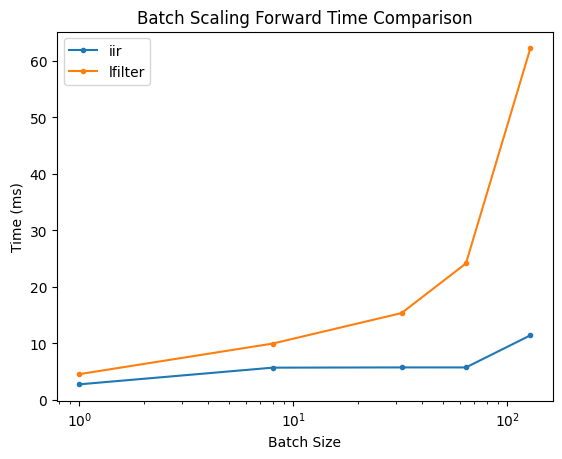

In [18]:
import matplotlib.pyplot as plt

plt.plot(Bs, f_cuda, marker='.', label='iir')
plt.plot(Bs, f_torch, marker='.', label='lfilter')

plt.xscale('log')
plt.title('Batch Scaling Forward Time Comparison')
plt.xlabel('Batch Size')
plt.ylabel('Time (ms)')
plt.legend()

plt.show()

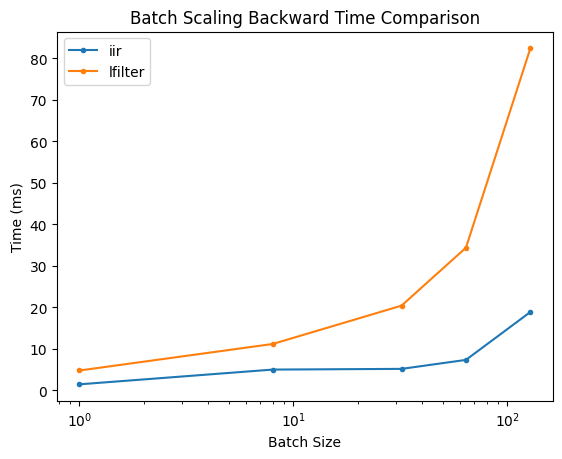

In [19]:
plt.plot(Bs, b_cuda, marker='.', label='iir')
plt.plot(Bs, b_torch, marker='.', label='lfilter')

plt.xscale('log')
plt.title('Batch Scaling Backward Time Comparison')
plt.xlabel('Batch Size')
plt.ylabel('Time (ms)')
plt.legend()

plt.show()

### Scaling with T

In [20]:
B = 32
Ts = [512, 2048, 8192, 16384]

In [21]:
f_cuda = []
f_torch = []

for T in Ts:
    x = get_x(B, T)
    f_cuda.append(benchmark_forward(cuda_model, x))
    f_torch.append(benchmark_forward(torch_model, x))

In [22]:
b_cuda = []
b_torch = []

for T in Ts:
    x = get_x(B, T)
    with torch.no_grad():
        grad_out = torch.randn_like(cuda_model(x))

    b_cuda.append(benchmark_backward(cuda_model, x, grad_out))
    b_torch.append(benchmark_backward(torch_model, x, grad_out))

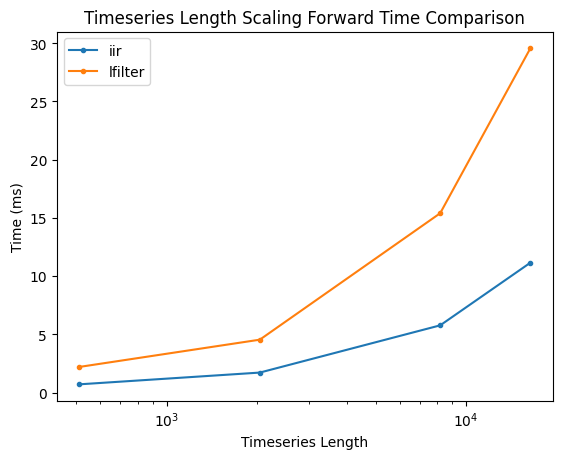

In [23]:
plt.plot(Ts, f_cuda, marker='.', label='iir')
plt.plot(Ts, f_torch, marker='.', label='lfilter')

plt.xscale('log')
plt.title('Timeseries Length Scaling Forward Time Comparison')
plt.xlabel('Timeseries Length')
plt.ylabel('Time (ms)')
plt.legend()

plt.show()

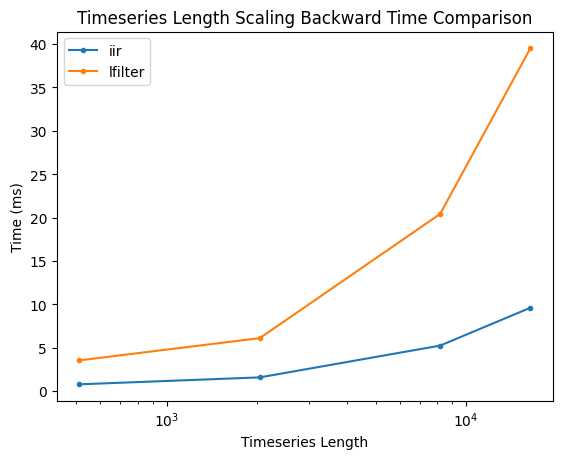

In [24]:
plt.plot(Ts, b_cuda, marker='.', label='iir')
plt.plot(Ts, b_torch, marker='.', label='lfilter')

plt.xscale('log')
plt.title('Timeseries Length Scaling Backward Time Comparison')
plt.xlabel('Timeseries Length')
plt.ylabel('Time (ms)')
plt.legend()

plt.show()